# Enhancing Medical Image Representation using DRL and Transfer Learning

## Objective
This project aims to improve medical image representation using:
- Transfer Learning (CNN pretrained models)
- Deep Reinforcement Learning (DRL)
- Domain Adaptation techniques

We evaluate whether these techniques improve classification performance on medical images such as chest X-rays.

## Dataset Description

We use a chest X-ray dataset containing two classes:
- NORMAL
- PNEUMONIA

The dataset is split into:
- Train
- Validation
- Test

# Imports + path

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import torch
import torch.nn as nn
import pandas as pd
import json

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from baseline_model import get_model
from dataset import get_dataloaders
from preprocessing import get_baseline_transforms
from evaluate import evaluate

In [2]:
from torchvision.datasets import ImageFolder

for split in ["train", "val", "test"]:
    ds = ImageFolder(f"../data_target/{split}")
    print(split, len(ds), ds.class_to_idx)

    normal = sum(1 for _, label in ds.samples if label == ds.class_to_idx["NORMAL"])
    pneumonia = sum(1 for _, label in ds.samples if label == ds.class_to_idx["PNEUMONIA"])

    print("NORMAL:", normal)
    print("PNEUMONIA:", pneumonia)
    print()

train 5216 {'NORMAL': 0, 'PNEUMONIA': 1}
NORMAL: 1341
PNEUMONIA: 3875

val 16 {'NORMAL': 0, 'PNEUMONIA': 1}
NORMAL: 8
PNEUMONIA: 8

test 485 {'NORMAL': 0, 'PNEUMONIA': 1}
NORMAL: 234
PNEUMONIA: 251



In [3]:
from pathlib import Path
import hashlib


def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def collect_hashes(folder):
    hashes = {}

    for path in Path(folder).rglob("*"):
        if path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            hashes[file_hash(path)] = str(path)

    return hashes


train_hashes = collect_hashes("../data_target/train")
val_hashes = collect_hashes("../data_target/val")
test_hashes = collect_hashes("../data_target/test")

print("Train/Val overlap:", len(set(train_hashes) & set(val_hashes)))
print("Train/Test overlap:", len(set(train_hashes) & set(test_hashes)))
print("Val/Test overlap:", len(set(val_hashes) & set(test_hashes)))

Train/Val overlap: 0
Train/Test overlap: 0
Val/Test overlap: 0


# device + dataloaders

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, val_loader, test_loader = get_dataloaders(
    "../data_resplit/train",
    "../data_resplit/val",
    "../data_resplit/test",
    train_transform=get_baseline_transforms(),
    eval_transform=get_baseline_transforms(),
    batch_size=32
)

print("Device:", device)
print("Train:", len(train_loader.dataset))
print("Validation:", len(val_loader.dataset))
print("Test:", len(test_loader.dataset))
print("Classes:", test_loader.dataset.class_to_idx)

Device: cpu
Train: 5970
Validation: 1278
Test: 1282
Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


# helper function to get metrics

In [3]:
def get_metrics(model, dataloader, device):
    model.eval()

    predictions = []
    labels_list = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            predictions.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_list, predictions)

    return acc, predictions, labels_list

# evaluate baseline CNN

In [4]:
baseline_model = get_model()

baseline_model.load_state_dict(
    torch.load("../models/best_baseline.pth", map_location=device)
)

baseline_model = baseline_model.to(device)

baseline_acc, baseline_preds, baseline_labels = get_metrics(
    baseline_model,
    test_loader,
    device
)

print("BASELINE CNN")
print("Accuracy:", baseline_acc)
print(classification_report(baseline_labels, baseline_preds))
print(confusion_matrix(baseline_labels, baseline_preds))

BASELINE CNN
Accuracy: 0.9797191887675507
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       641
           1       0.99      0.97      0.98       641

    accuracy                           0.98      1282
   macro avg       0.98      0.98      0.98      1282
weighted avg       0.98      0.98      0.98      1282

[[632   9]
 [ 17 624]]


# show DRL learned policy

In [6]:
import json

with open("../results/rl_policy.json", "r") as f:
    rl_policy = json.load(f)

print("DRL POLICY")
print(rl_policy)

best_sequence = rl_policy["best_sequence_actions"]

action_names = [
    rl_policy["actions"][str(action)]
    for action in best_sequence
]

print("Selected sequence:", best_sequence)
print("Selected augmentations:", action_names)
print("Best average reward:", rl_policy["best_average_reward"])
print("Reward formula:", rl_policy["reward_formula"])

DRL POLICY
{'best_sequence': '0', 'best_sequence_actions': [0], 'best_average_reward': 0.0, 'average_sequence_rewards': {'7-7-8-3': -0.05125514507293701, '7-3-0': -0.020042200088500977, '1-0': -0.01001978874206543, '7-6-0': -0.020002026557922364, '2-5-8-3': -0.040002384185791016, '0': 0.0, '8-1-8-2': -0.04, '6-1-3-3': -0.3071515345573425, '5-0': -0.01172954797744751, '5-1-7-3': -0.9671506294608117, '4-7-7-0': -0.07217511415481567, '1-8-5-0': -0.050003795623779296, '8-0': -0.010048557917277018, '2-7-0': -0.02000131130218506, '5-7-3-1': -0.2406199359893799, '4-1-7-6': -0.05423323154449463, '2-5-8-0': -0.03520038604736328, '6-3-0': -0.020105738639831543, '2-5-8-8': -0.0399997615814209, '2-2-4-7': -0.0399544620513916, '7-8-8-0': -0.03510621070861816, '1-6-5-5': -0.04057554244995117, '8-3-2-8': -0.04, '1-6-2-6': -0.9914402337372303, '3-0': -0.041347960233688356, '8-2-2-6': -0.039985337257385255, '2-2-2-5': -0.04713348388671875, '1-2-8-6': -0.039979138374328614, '2-5-7-3': -0.043632545471191

# evaluate DRL-Augmented CNN

In [7]:
drl_model = get_model()

drl_model.load_state_dict(
    torch.load("../models/best_drl.pth", map_location=device)
)

drl_model = drl_model.to(device)

drl_acc, drl_preds, drl_labels = get_metrics(
    drl_model,
    test_loader,
    device
)

print("DRL-AUGMENTED CNN")
print("Accuracy:", drl_acc)
print(classification_report(drl_labels, drl_preds))
print(confusion_matrix(drl_labels, drl_preds))

DRL-AUGMENTED CNN
Accuracy: 0.9742589703588144
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       641
           1       0.98      0.97      0.97       641

    accuracy                           0.97      1282
   macro avg       0.97      0.97      0.97      1282
weighted avg       0.97      0.97      0.97      1282

[[629  12]
 [ 21 620]]


# evaluate CORAL Domain Adaptation

In [10]:
from feature_extraction import FeatureExtractor
import torch.nn as nn

feature_extractor = FeatureExtractor().to(device)
classifier = nn.Linear(2048, 2).to(device)

checkpoint = torch.load(
    "../models/best_drl_coral.pth",
    map_location=device
)

feature_extractor.load_state_dict(checkpoint["feature_extractor"])
classifier.load_state_dict(checkpoint["classifier"])

feature_extractor.eval()
classifier.eval()

drl_coral_predictions = []
drl_coral_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        features = feature_extractor(images)
        outputs = classifier(features)

        preds = outputs.argmax(dim=1)

        drl_coral_predictions.extend(preds.cpu().numpy())
        drl_coral_labels.extend(labels.cpu().numpy())

drl_coral_acc = accuracy_score(
    drl_coral_labels,
    drl_coral_predictions
)

print("DRL + CNN + CORAL")
print("Accuracy:", drl_coral_acc)
print(classification_report(drl_coral_labels, drl_coral_predictions))
print(confusion_matrix(drl_coral_labels, drl_coral_predictions))

DRL + CNN + CORAL
Accuracy: 0.953198127925117
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       641
           1       0.99      0.92      0.95       641

    accuracy                           0.95      1282
   macro avg       0.96      0.95      0.95      1282
weighted avg       0.96      0.95      0.95      1282

[[635   6]
 [ 54 587]]


# final comparison table

In [12]:
results = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "DRL + CNN",
        "DRL + CNN + CORAL"
    ],
    "Description": [
        "ResNet50 transfer learning without DRL",
        f"CNN trained with PPO-selected medical augmentation",
        f"DRL-selected augmentation + CORAL feature alignment"
    ],
    "Accuracy": [
        baseline_acc,
        drl_acc,
        drl_coral_acc
    ]
})

results

,Model,Description,Accuracy
0,Baseline CNN,ResNet50 transfer learning without DRL,0.979719
1,DRL + CNN,CNN trained with PPO-selected medical augmenta...,0.974259
2,DRL + CNN + CORAL,DRL-selected augmentation + CORAL feature alig...,0.953198


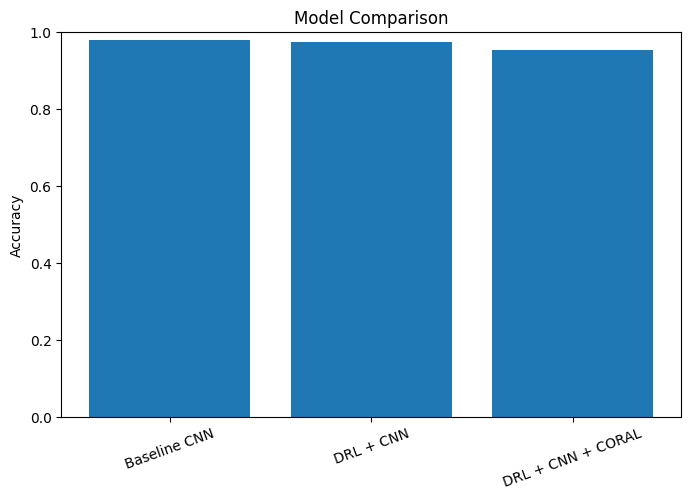

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

# Dataset 2 loader

In [14]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

from preprocessing import get_baseline_transforms

target_test_dataset = ImageFolder(
    "../data_target/test",
    transform=get_baseline_transforms()
)

target_test_loader = DataLoader(
    target_test_dataset,
    batch_size=32,
    shuffle=False
)

print("Target test size:", len(target_test_dataset))
print("Target classes:", target_test_dataset.class_to_idx)

Target test size: 485
Target classes: {'NORMAL': 0, 'PNEUMONIA': 1}


# Evaluate baseline on Dataset 2

In [15]:
print("BASELINE CNN ON DATASET 2")

target_baseline_acc, target_baseline_preds, target_baseline_labels = get_metrics(
    baseline_model,
    target_test_loader,
    device
)

print("Accuracy:", target_baseline_acc)
print(classification_report(target_baseline_labels, target_baseline_preds))
print(confusion_matrix(target_baseline_labels, target_baseline_preds))

BASELINE CNN ON DATASET 2
Accuracy: 0.9752577319587629
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       234
           1       0.95      1.00      0.98       251

    accuracy                           0.98       485
   macro avg       0.98      0.97      0.98       485
weighted avg       0.98      0.98      0.98       485

[[222  12]
 [  0 251]]


# Evaluate DRL + CNN + CORAL on Dataset 2

In [16]:
feature_extractor.eval()
classifier.eval()

target_coral_predictions = []
target_coral_labels = []

with torch.no_grad():

    for images, labels in target_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        features = feature_extractor(images)
        outputs = classifier(features)

        preds = outputs.argmax(dim=1)

        target_coral_predictions.extend(preds.cpu().numpy())
        target_coral_labels.extend(labels.cpu().numpy())

target_drl_coral_acc = accuracy_score(
    target_coral_labels,
    target_coral_predictions
)

print("DRL + CNN + CORAL ON DATASET 2")
print("Accuracy:", target_drl_coral_acc)
print(classification_report(target_coral_labels, target_coral_predictions))
print(confusion_matrix(target_coral_labels, target_coral_predictions))

DRL + CNN + CORAL ON DATASET 2
Accuracy: 0.9670103092783505
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       234
           1       0.97      0.96      0.97       251

    accuracy                           0.97       485
   macro avg       0.97      0.97      0.97       485
weighted avg       0.97      0.97      0.97       485

[[227   7]
 [  9 242]]


# Final comparison table

In [17]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN",
        "DRL + CNN",
        "DRL + CNN + CORAL",
        "Baseline CNN",
        "DRL + CNN",
        "DRL + CNN + CORAL"
    ],
    "Dataset": [
        "Dataset 1 test",
        "Dataset 1 test",
        "Dataset 1 test",
        "Dataset 2 test",
        "Dataset 2 test",
        "Dataset 2 test"
    ],
    "Accuracy": [
        baseline_acc,
        drl_acc,
        drl_coral_acc,
        target_baseline_acc,
        target_drl_acc,
        target_drl_coral_acc
    ]
})

comparison

NameError: name 'target_drl_acc' is not defined